# POS Tagging Using RNN: 
To use RNNs to tag words in an English corpus with their part-of-speech (POS) tag.

# Summary
1. Preprocessing data
2. Vanilla RNN
3. Word Embeddings
4. LSTM
5. GRU
6. Bidirectional LSTM
7. Model Evaluation

In [2]:
!pip install gensim


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\sksha\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB 8.3 MB/s eta 0:00:03
    --------------------------------------- 0.3/24.4 MB 4.7 MB/s eta 0:00:06
    --------------------------------------- 0.4/24.4 MB 3.5 MB/s eta 0:00:07
    --------------------------------------- 0.5/24.4 MB 3.0 MB/s eta 0:00:08
   - -------------------------------------- 0.6/24.4 MB 2.8 MB/s eta 0:00:09
   - -------------------------------------- 0.7/24.4 MB 2.7 MB/s eta 0:00:09
   - -------------------------------------- 0.8/24.4 MB 2.5 MB/s eta 0:00:10
   - -------------------------------------- 0.9/24.4 MB 2.4 MB/s eta 0:00:10
   - -------------------------------------- 1.0/24.4 MB 2.4 MB/s eta 0:00:10
   - -------------------------------------- 1.1/24.4 MB 2.3 MB/s eta 0:00:11
   - -------------------------------------- 1.1/24.4 MB 2.3 MB/s eta 0:00:10
   -- ------------------------------------- 1.2/24.4 MB 2.2 MB/s eta 0:00:11
   -- 

In [4]:
!pip install keras


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\sksha\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [5]:
# import necessary libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# brown → general English text corpus
# treebank → annotated grammar structure
# conll2000 → chunking dataset (phrase detection)

from nltk.corpus import brown
from nltk.corpus import treebank
from nltk.corpus import conll2000

#Converts words into numerical vectors.
from gensim.models import KeyedVectors

#Converts words → numbers
from tensorflow.keras.preprocessing.text import Tokenizer

# Makes all sequences same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Converts labels into one-hot encoding
from tensorflow.keras.utils import to_categorical

# Model building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, SimpleRNN, RNN
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# 1. Preprocess data

In [6]:
# tagged_sents() returns sentences where each word is paired with a POS tag.
treebank_corpus = treebank.tagged_sents(tagset='universal')
brown_corpus = brown.tagged_sents(tagset='universal')
conll_corpus = conll2000.tagged_sents(tagset='universal')
tagged_sentences = treebank_corpus + brown_corpus + conll_corpus

In [7]:
tagged_sentences[11]

[('``', '.'),
 ('We', 'PRON'),
 ('have', 'VERB'),
 ('no', 'DET'),
 ('useful', 'ADJ'),
 ('information', 'NOUN'),
 ('on', 'ADP'),
 ('whether', 'ADP'),
 ('users', 'NOUN'),
 ('are', 'VERB'),
 ('at', 'ADP'),
 ('risk', 'NOUN'),
 (',', '.'),
 ("''", '.'),
 ('said', 'VERB'),
 ('*T*-1', 'X'),
 ('James', 'NOUN'),
 ('A.', 'NOUN'),
 ('Talcott', 'NOUN'),
 ('of', 'ADP'),
 ('Boston', 'NOUN'),
 ("'s", 'PRT'),
 ('Dana-Farber', 'NOUN'),
 ('Cancer', 'NOUN'),
 ('Institute', 'NOUN'),
 ('.', '.')]

## Divide data in words (X) and tags (Y)

Since this is a **many-to-many** problem, each data point will be a different sentence of the corpora.

Each data point will have multiple words in the **input sequence**. This is what we will refer to as **X**.

Each word will have its correpsonding tag in the **output sequence**. This what we will refer to as **Y**.

In [8]:
X=[]
Y=[]
for sentence in tagged_sentences:
    X_sentence=[]
    Y_sentence=[]
    for entity in sentence:
        X_sentence.append(entity[0])
        Y_sentence.append(entity[1])
    X.append(X_sentence)
    Y.append(Y_sentence)

In [9]:
num_words=len(set([word.lower() for sentence in X for word in sentence]))
num_tags=len(set([word.lower() for sentence in Y for word in sentence]))

In [10]:
print(num_words)

59448


In [11]:
print(num_tags)

12


In [12]:
print("Total no of sentences: ",len(X))
print("Vocabulary size: ",num_words)
print("Total no of tags: ",num_tags)

Total no of sentences:  72202
Vocabulary size:  59448
Total no of tags:  12


In [13]:
print('sample X: ',X[0],'\n')
print('sample Y: ',Y[0],'\n')

sample X:  ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.'] 

sample Y:  ['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.'] 



In [14]:
# In this many-to-many problem, the length of each input and output sequence must be the same.
# Since each word is tagged, it's important to make sure that the length of input sequence equals the output sequence
print("Length of first input sequence: ",len(X[0]))
print("Length of first output sequence: ",len(Y[0]))

Length of first input sequence:  18
Length of first output sequence:  18


# Encode X and Y to integer values
using the Tokenizer() function from Keras library to encode text sequence to integer sequence

In [15]:
word_tokenizer=Tokenizer()
word_tokenizer.fit_on_texts(X)

In [16]:
X_encoded=word_tokenizer.texts_to_sequences(X)

In [17]:
tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(Y)
Y_encoded = tag_tokenizer.texts_to_sequences(Y)

In [18]:
print("Raw data point: ","\n")
print('X: ', X[0], '\n')
print('Y: ', Y[0], '\n')
print()
print("Encoded data point: ","\n")
print('X: ', X_encoded[0], '\n')
print('Y: ', Y_encoded[0], '\n')

Raw data point:  

X:  ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.'] 

Y:  ['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.'] 


Encoded data point:  

X:  [6423, 24231, 2, 7652, 102, 170, 2, 47, 1898, 1, 269, 17, 7, 13230, 619, 1711, 2761, 3] 

Y:  [1, 1, 3, 11, 1, 6, 3, 2, 2, 5, 1, 4, 5, 6, 1, 1, 11, 3] 



In [19]:
diff_len=[1 if len(input)!=len(output) else 0 for input,output in zip(X_encoded,Y_encoded)]
print("Total mismatched sentences: ",sum(diff_len))

Total mismatched sentences:  0


# Pad sequence

The next step after encoding the data is to **define the sequence lengths**. As of now, the sentences present in the data are of various lengths. We need to either pad short sentences or truncate long sentences to a fixed length. This fixed length, however, is a **hyperparameter**.

In [20]:
# check length of longest sentence
lengths = [len(seq) for seq in X_encoded]
print("Length of longest sentence: ",max(lengths))

Length of longest sentence:  271


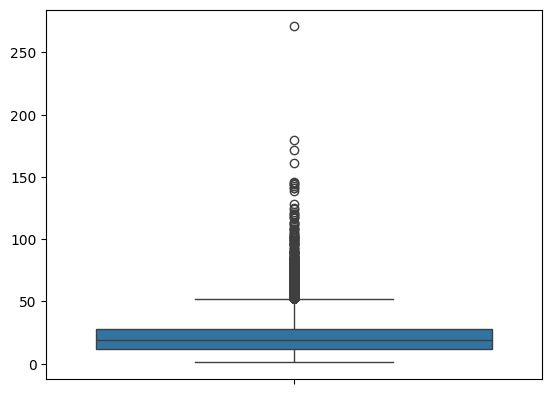

In [21]:
sns.boxplot(lengths)
plt.show()

Pad each sequence to MAX_SEQ_LENGTH using KERAS' pad_sequences() function. 
Sentences longer than MAX_SEQ_LENGTH are truncated.
Sentences shorter than MAX_SEQ_LENGTH are padded with zeroes.

Truncation and padding can either be 'pre' or 'post'. 
For padding we are using 'pre' padding type, that is, add zeroes on the left side.
For truncation, we are using 'post', that is, truncate a sentence from right side.

In [22]:
MAX_SEQ_LENGTH=100
X_padded=pad_sequences(X_encoded,maxlen=MAX_SEQ_LENGTH, padding="pre",truncating="post")
Y_padded=pad_sequences(Y_encoded,maxlen=MAX_SEQ_LENGTH, padding="pre",truncating="post")


In [23]:
print(X_padded[0],"\n")
print(Y_padded[0])

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0  6423 24231
     2  7652   102   170     2    47  1898     1   269    17     7 13230
   619  1711  2761     3] 

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  1  1  3 11  1  6  3  2  2  5  1  4  5  6
  1  1 11  3]


RNN will learn the zero to zero mapping while training. So,don't need to worry about the padded zeroes. Here, zero is not reserved for any word or tag, it's only reserved for padding.

In [24]:
# assign padded sequences to X and Y
X, Y = X_padded, Y_padded

## Word embeddings

Currently, each word and each tag is encoded as an integer. 

We'll use a more sophisticated technique to represent the input words (X) using what's known as **word embeddings**.

However, to represent each tag in Y, we'll simply use **one-hot encoding** scheme since there are only 13 tags in the dataset and the LSTM will have no problems in learning its own representation of these tags.

# Use word embeddings for input sequences (X)

## GoogleNews-vectors-negative300
pre-trained embedding file.These files contain Words and their vector representations

In [26]:
path = 'GoogleNews-vectors-negative300.bin'
# load word2vec using the following function present in the gensim library
word2vec = KeyedVectors.load_word2vec_format(path, binary=True)

In [27]:
# word2vec effectiveness
word2vec.most_similar(positive = ["King", "Woman"], negative = ["Man"])

[('Queen', 0.4929387867450714),
 ('Tupou_V.', 0.45174285769462585),
 ('Oprah_BFF_Gayle', 0.4422132968902588),
 ('Jackson', 0.440250426530838),
 ('NECN_Alison', 0.4331282675266266),
 ('Whitfield', 0.42834725975990295),
 ('Ida_Vandross', 0.42084527015686035),
 ('prosecutor_Dan_Satterberg', 0.420758992433548),
 ('martin_Luther_King', 0.42059651017189026),
 ('Coretta_King', 0.4202733635902405)]

In [28]:
# assign word vectors from word2vec model

EMBEDDING_SIZE  = 300  # each word in word2vec model is represented using a 300 dimensional vector
VOCABULARY_SIZE = len(word_tokenizer.word_index) + 1

# create an empty embedding matix
embedding_weights = np.zeros((VOCABULARY_SIZE, EMBEDDING_SIZE))

# create a word to index dictionary mapping
word2id = word_tokenizer.word_index

# copy vectors from word2vec model to the words present in corpus
for word, index in word2id.items():
    try:
        embedding_weights[index, :] = word2vec[word]
    except KeyError:
        pass

In [29]:
# check embedding dimension
print("Embeddings shape: ",embedding_weights.shape)

Embeddings shape:  (59449, 300)


In [30]:
embedding_weights[word_tokenizer.word_index['useful']]

array([ 0.01794434, -0.05810547,  0.15527344,  0.03149414, -0.2734375 ,
        0.23339844,  0.18359375,  0.14746094, -0.06982422,  0.0559082 ,
        0.07714844, -0.22851562,  0.07373047,  0.20703125,  0.04174805,
        0.09960938,  0.15039062, -0.00567627, -0.23925781, -0.23242188,
        0.21191406, -0.21777344, -0.39648438,  0.296875  , -0.01452637,
        0.02502441, -0.05053711, -0.05444336,  0.02441406, -0.04101562,
        0.04492188, -0.10986328,  0.05810547,  0.05834961,  0.04272461,
       -0.13183594, -0.17773438,  0.13574219,  0.07519531, -0.0534668 ,
        0.33984375,  0.19238281,  0.14648438,  0.08203125, -0.10009766,
       -0.16308594, -0.08691406,  0.12792969,  0.1015625 ,  0.09716797,
        0.03039551, -0.265625  , -0.0612793 , -0.19433594, -0.171875  ,
        0.08886719,  0.10546875, -0.3359375 ,  0.29492188, -0.02539062,
       -0.05126953, -0.15820312, -0.22851562, -0.05419922, -0.08984375,
        0.11572266, -0.14648438, -0.03015137, -0.26367188, -0.16

# Use one-hot encoding for output sequences (Y)

In [31]:
Y = to_categorical(Y)

In [32]:
print(Y.shape)

(72202, 100, 13)


# Split data in training, validation and tesing sets

In [33]:
TEST_SIZE = 0.15
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=TEST_SIZE, random_state=4)

In [34]:
# split training data into training and validation sets
VALID_SIZE = 0.15
X_train, X_validation, Y_train, Y_validation = train_test_split(X_train, Y_train, test_size=VALID_SIZE, random_state=4)

In [35]:
print("TRAINING DATA")
print('Shape of input sequences: ',X_train.shape)
print('Shape of output sequences: ',Y_train.shape)
print("\n")
print("VALIDATION DATA")
print('Shape of input sequences: ',X_validation.shape)
print('Shape of output sequences: ',Y_validation.shape)
print("\n")
print("TESTING DATA")
print('Shape of input sequences: ',X_test.shape)
print('Shape of output sequences: ',Y_test.shape)

TRAINING DATA
Shape of input sequences:  (52165, 100)
Shape of output sequences:  (52165, 100, 13)


VALIDATION DATA
Shape of input sequences:  (9206, 100)
Shape of output sequences:  (9206, 100, 13)


TESTING DATA
Shape of input sequences:  (10831, 100)
Shape of output sequences:  (10831, 100, 13)


# Vanilla RNN

## Uninitialised fixed embeddings
For this RNN we won't use the pre-trained word embeddings. We'll use randomly inititalised embeddings. Moreover, we won't update the embeddings weights.

In [36]:
# total number of tags
NUM_CLASSES = Y.shape[2]

In [37]:
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim     =  VOCABULARY_SIZE,         # number of unique words in data
                        output_dim    =  EMBEDDING_SIZE,          # length of vector with which each word is represented
                        input_length  =  MAX_SEQ_LENGTH,          # length of input sequence
                        trainable     =  False                    # False - don't update the embeddings
))

rnn_model.add(SimpleRNN(64, 
              return_sequences=True  # True - return whole sequence; False - return single output of the end of the sequence
))
rnn_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

In [38]:
rnn_model.compile(loss      =  'categorical_crossentropy',
                  optimizer =  'adam',
                  metrics   =  ['acc'])

In [40]:
rnn_training = rnn_model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_validation, Y_validation))

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 88s 165ms/step - acc: 0.8579 - loss: 0.4987 - val_acc: 0.8934 - val_loss: 0.3475
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 66s 161ms/step - acc: 0.9092 - loss: 0.2915 - val_acc: 0.9230 - val_loss: 0.2469
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 66s 161ms/step - acc: 0.9307 - loss: 0.2214 - val_acc: 0.9374 - val_loss: 0.1982
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 67s 163ms/step - acc: 0.9410 - loss: 0.1845 - val_acc: 0.9450 - val_loss: 0.1703
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 66s 162ms/step - acc: 0.9474 - loss: 0.1621 - val_acc: 0.9502 - val_loss: 0.1527
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 408s 1s/step - acc: 0.9515 - loss: 0.1480 - val_acc: 0.9531 - val_loss: 0.1426
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 50s 123ms/step - acc: 0.9540 - loss: 0.1390 - val_acc: 0.9552 - val_loss: 0.1348
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 77s 111ms/step - acc: 0.9557 - loss: 0.1329 - val_acc: 0.9567 - val_loss: 0.1299
Epoch 9/10
408/408 ━━━━━━━━━━━━━━━

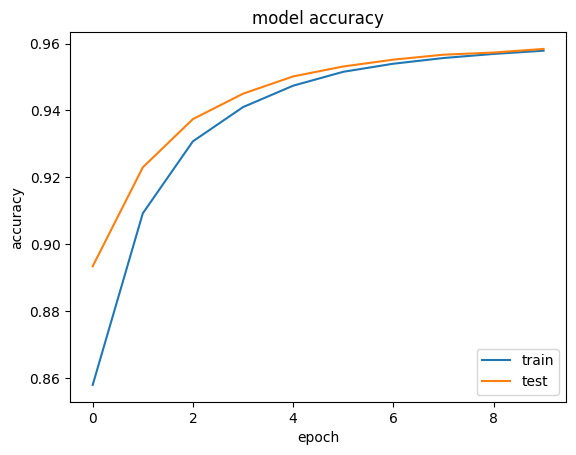

In [42]:
# visualise training history(training accuracy, validation accuracy)
plt.plot(rnn_training.history['acc'])
plt.plot(rnn_training.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

In [43]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 300)            │      17,834,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 100, 64)             │          23,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 100, 13)             │             845 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,907,317 (68.31 MB)

 Trainable params: 24,205 (94.55 KB)

 Non-trainable params: 17,834,700 (68.03 MB)

 Optimizer params: 48,412 (189.11 KB)

## Uninitialised trainable embeddings

In [44]:
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim     =  VOCABULARY_SIZE,         # number of unique words in data
                        output_dim    =  EMBEDDING_SIZE,          # length of vector with which each word is represented
                        input_length  =  MAX_SEQ_LENGTH,          # length of input sequence
                        trainable     =  True                    # False - don't update the embeddings
))

rnn_model.add(SimpleRNN(64, 
              return_sequences=True  # True - return whole sequence; False - return single output of the end of the sequence
))
rnn_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

In [45]:
rnn_model.compile(loss      =  'categorical_crossentropy',
                  optimizer =  'adam',
                  metrics   =  ['acc'])

In [46]:
rnn_training = rnn_model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_validation, Y_validation))

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 168s 332ms/step - acc: 0.9638 - loss: 0.1388 - val_acc: 0.9877 - val_loss: 0.0392
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 139s 339ms/step - acc: 0.9903 - loss: 0.0292 - val_acc: 0.9900 - val_loss: 0.0286
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 128s 313ms/step - acc: 0.9928 - loss: 0.0206 - val_acc: 0.9906 - val_loss: 0.0265
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 125s 307ms/step - acc: 0.9940 - loss: 0.0170 - val_acc: 0.9907 - val_loss: 0.0262
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 130s 317ms/step - acc: 0.9949 - loss: 0.0145 - val_acc: 0.9906 - val_loss: 0.0269
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 126s 309ms/step - acc: 0.9957 - loss: 0.0124 - val_acc: 0.9905 - val_loss: 0.0278
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 111s 273ms/step - acc: 0.9965 - loss: 0.0105 - val_acc: 0.9903 - val_loss: 0.0295
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 109s 268ms/step - acc: 0.9971 - loss: 0.0088 - val_acc: 0.9900 - val_loss: 0.0313
Epoch 9/10
408/408 ━━━━━

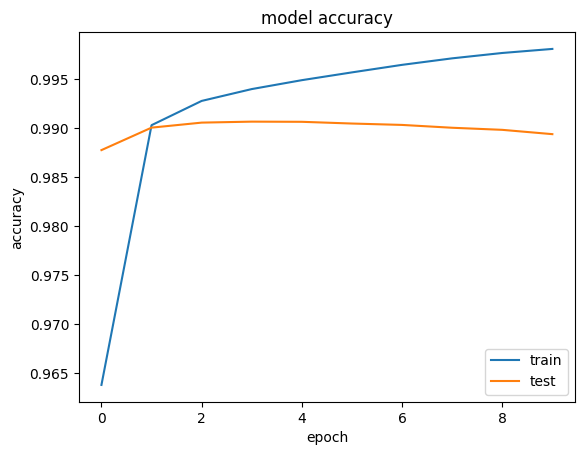

In [47]:
plt.plot(rnn_training.history['acc'])
plt.plot(rnn_training.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

In [48]:
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 100, 300)            │      17,834,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 100, 64)             │          23,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 100, 13)             │             845 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,576,717 (204.38 MB)

 Trainable params: 17,858,905 (68.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,717,812 (136.25 MB)

## Using pre-trained embedding weights

In [49]:
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim     =  VOCABULARY_SIZE,         # number of unique words in data
                        output_dim    =  EMBEDDING_SIZE,          # length of vector with which each word is represented
                        input_length  =  MAX_SEQ_LENGTH,          # length of input sequence
                        weights       = [embedding_weights],      # word embedding matrix
                        trainable     =  True                     # False - don't update the embeddings
))

rnn_model.add(SimpleRNN(64, 
              return_sequences=True  # True - return whole sequence; False - return single output of the end of the sequence
))
rnn_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

In [50]:
rnn_model.compile(loss      =  'categorical_crossentropy',
                  optimizer =  'adam',
                  metrics   =  ['acc'])

In [51]:
rnn_training = rnn_model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_validation, Y_validation))

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 124s 284ms/step - acc: 0.9727 - loss: 0.1109 - val_acc: 0.9895 - val_loss: 0.0318
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 101s 248ms/step - acc: 0.9913 - loss: 0.0251 - val_acc: 0.9908 - val_loss: 0.0255
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 100s 245ms/step - acc: 0.9931 - loss: 0.0191 - val_acc: 0.9913 - val_loss: 0.0241
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 100s 245ms/step - acc: 0.9941 - loss: 0.0163 - val_acc: 0.9914 - val_loss: 0.0240
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 103s 251ms/step - acc: 0.9949 - loss: 0.0141 - val_acc: 0.9914 - val_loss: 0.0242
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 109s 266ms/step - acc: 0.9957 - loss: 0.0122 - val_acc: 0.9912 - val_loss: 0.0253
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 124s 303ms/step - acc: 0.9964 - loss: 0.0104 - val_acc: 0.9908 - val_loss: 0.0267
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 126s 309ms/step - acc: 0.9971 - loss: 0.0088 - val_acc: 0.9907 - val_loss: 0.0287
Epoch 9/10
408/408 ━━━━━

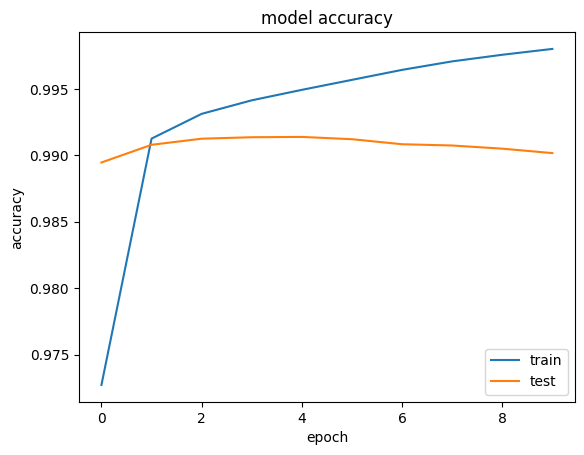

In [52]:
plt.plot(rnn_training.history['acc'])
plt.plot(rnn_training.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

In [53]:
rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 100, 300)            │      17,834,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 100, 64)             │          23,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 100, 13)             │             845 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,576,717 (204.38 MB)

 Trainable params: 17,858,905 (68.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,717,812 (136.25 MB)

# LSTM

In [54]:
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim     =  VOCABULARY_SIZE,         # number of unique words in data
                        output_dim    =  EMBEDDING_SIZE,          # length of vector with which each word is represented
                        input_length  =  MAX_SEQ_LENGTH,          # length of input sequence
                        weights       = [embedding_weights],      # word embedding matrix
                        trainable     =  True                     # False - don't update the embeddings
))

lstm_model.add(LSTM(64, 
              return_sequences=True  # True - return whole sequence; False - return single output of the end of the sequence
))
lstm_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

In [55]:
lstm_model.compile(loss      =  'categorical_crossentropy',
                   optimizer =  'adam',
                   metrics   =  ['acc'])

In [56]:
lstm_training = lstm_model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_validation, Y_validation))

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 205s 445ms/step - acc: 0.9603 - loss: 0.1466 - val_acc: 0.9891 - val_loss: 0.0341
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 176s 431ms/step - acc: 0.9908 - loss: 0.0268 - val_acc: 0.9910 - val_loss: 0.0258
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 173s 424ms/step - acc: 0.9928 - loss: 0.0201 - val_acc: 0.9913 - val_loss: 0.0240
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 130s 318ms/step - acc: 0.9938 - loss: 0.0172 - val_acc: 0.9916 - val_loss: 0.0231
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 136s 332ms/step - acc: 0.9945 - loss: 0.0152 - val_acc: 0.9917 - val_loss: 0.0229
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 137s 336ms/step - acc: 0.9951 - loss: 0.0134 - val_acc: 0.9918 - val_loss: 0.0231
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 137s 335ms/step - acc: 0.9958 - loss: 0.0118 - val_acc: 0.9918 - val_loss: 0.0235
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 139s 339ms/step - acc: 0.9963 - loss: 0.0104 - val_acc: 0.9918 - val_loss: 0.0244
Epoch 9/10
408/408 ━━━━━

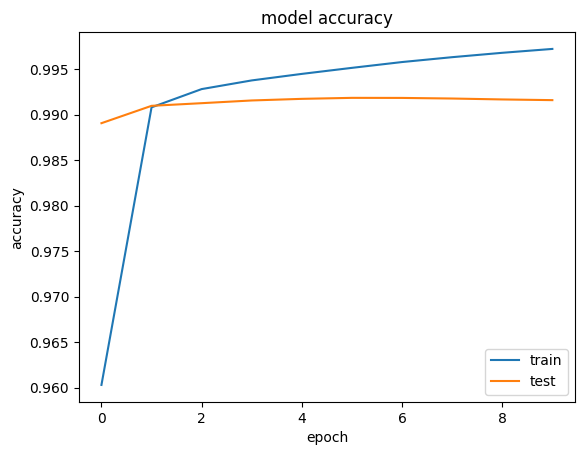

In [57]:
plt.plot(lstm_training.history['acc'])
plt.plot(lstm_training.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

In [58]:
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 100, 300)            │      17,834,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 100, 64)             │          93,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 100, 13)             │             845 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,786,957 (205.18 MB)

 Trainable params: 17,928,985 (68.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,857,972 (136.79 MB)

# GRU

In [62]:
gru_model = Sequential()
gru_model.add(Embedding(input_dim     =  VOCABULARY_SIZE,         # number of unique words in data
                        output_dim    =  EMBEDDING_SIZE,          # length of vector with which each word is represented
                        input_length  =  MAX_SEQ_LENGTH,          # length of input sequence
                        weights       = [embedding_weights],      # word embedding matrix
                        trainable     =  True                     # False - don't update the embeddings
))

gru_model.add(GRU(64, 
              return_sequences=True  # True - return whole sequence; False - return single output of the end of the sequence
))
gru_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

In [63]:
gru_model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['acc'])

In [64]:
gru_training = gru_model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_validation, Y_validation))

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 208s 453ms/step - acc: 0.9732 - loss: 0.1041 - val_acc: 0.9897 - val_loss: 0.0297
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 159s 390ms/step - acc: 0.9913 - loss: 0.0242 - val_acc: 0.9910 - val_loss: 0.0245
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 155s 380ms/step - acc: 0.9930 - loss: 0.0190 - val_acc: 0.9915 - val_loss: 0.0231
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 147s 355ms/step - acc: 0.9937 - loss: 0.0167 - val_acc: 0.9917 - val_loss: 0.0226
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 145s 356ms/step - acc: 0.9943 - loss: 0.0150 - val_acc: 0.9918 - val_loss: 0.0227
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 125s 307ms/step - acc: 0.9948 - loss: 0.0137 - val_acc: 0.9919 - val_loss: 0.0229
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 124s 303ms/step - acc: 0.9954 - loss: 0.0125 - val_acc: 0.9918 - val_loss: 0.0235
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 133s 327ms/step - acc: 0.9958 - loss: 0.0113 - val_acc: 0.9918 - val_loss: 0.0244
Epoch 9/10
408/408 ━━━━━

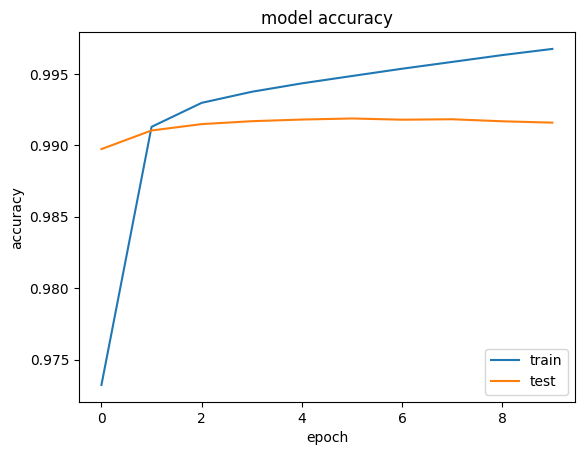

In [65]:
plt.plot(gru_training.history['acc'])
plt.plot(gru_training.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

In [66]:
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ (None, 100, 300)            │      17,834,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 100, 64)             │          70,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_5 (TimeDistributed) │ (None, 100, 13)             │             845 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,717,453 (204.92 MB)

 Trainable params: 17,905,817 (68.31 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,811,636 (136.61 MB)

# Bidirectional LSTM

In [67]:
bidirect_model = Sequential()
bidirect_model.add(Embedding(input_dim     = VOCABULARY_SIZE,
                             output_dim    = EMBEDDING_SIZE,
                             input_length  = MAX_SEQ_LENGTH,
                             weights       = [embedding_weights],
                             trainable     = True
))
bidirect_model.add(Bidirectional(LSTM(64, return_sequences=True)))
bidirect_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

In [68]:
bidirect_model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['acc'])

In [69]:
bidirect_training = bidirect_model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_validation, Y_validation))

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 270s 607ms/step - acc: 0.9653 - loss: 0.1189 - val_acc: 0.9921 - val_loss: 0.0247
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 246s 602ms/step - acc: 0.9938 - loss: 0.0191 - val_acc: 0.9937 - val_loss: 0.0190
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 420s 1s/step - acc: 0.9955 - loss: 0.0135 - val_acc: 0.9942 - val_loss: 0.0172
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 245s 601ms/step - acc: 0.9965 - loss: 0.0105 - val_acc: 0.9945 - val_loss: 0.0165
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 244s 597ms/step - acc: 0.9973 - loss: 0.0082 - val_acc: 0.9947 - val_loss: 0.0161
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 344s 844ms/step - acc: 0.9980 - loss: 0.0064 - val_acc: 0.9947 - val_loss: 0.0168
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 244s 597ms/step - acc: 0.9985 - loss: 0.0049 - val_acc: 0.9945 - val_loss: 0.0179
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 240s 588ms/step - acc: 0.9989 - loss: 0.0037 - val_acc: 0.9944 - val_loss: 0.0190
Epoch 9/10
408/408 ━━━━━━━━

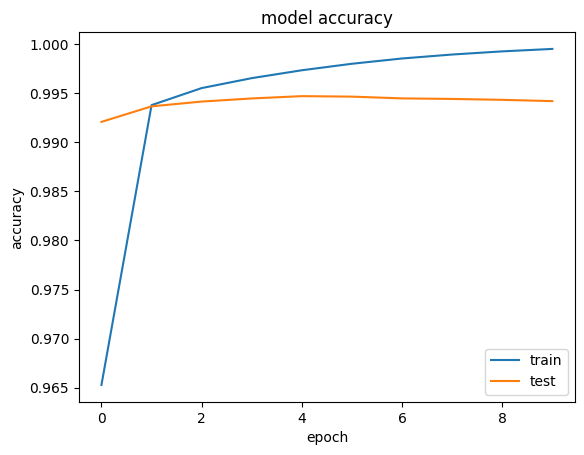

In [70]:
plt.plot(bidirect_training.history['acc'])
plt.plot(bidirect_training.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

In [71]:
bidirect_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ (None, 100, 300)            │      17,834,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 100, 128)            │         186,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_6 (TimeDistributed) │ (None, 100, 13)             │           1,677 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 54,069,773 (206.26 MB)

 Trainable params: 18,023,257 (68.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36,046,516 (137.51 MB)

#  Model evaluation

In [72]:
loss, accuracy = rnn_model.evaluate(X_test, Y_test, verbose = 1)
print("Loss: {0},\nAccuracy: {1}".format(loss, accuracy))

339/339 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - acc: 0.9903 - loss: 0.0332
Loss: 0.03315342590212822,
Accuracy: 0.9902642369270325


In [73]:
loss, accuracy = lstm_model.evaluate(X_test, Y_test, verbose = 1)
print("Loss: {0},\nAccuracy: {1}".format(loss, accuracy))

339/339 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - acc: 0.9916 - loss: 0.0266
Loss: 0.02655995823442936,
Accuracy: 0.9915805459022522


In [74]:
loss, accuracy = gru_model.evaluate(X_test, Y_test, verbose = 1)
print("Loss: {0},\nAccuracy: {1}".format(loss, accuracy))

339/339 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - acc: 0.9917 - loss: 0.0263
Loss: 0.026252543553709984,
Accuracy: 0.99166339635849


In [75]:
loss, accuracy = bidirect_model.evaluate(X_test, Y_test, verbose = 1)
print("Loss: {0},\nAccuracy: {1}".format(loss, accuracy))

339/339 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - acc: 0.9943 - loss: 0.0220
Loss: 0.02201884612441063,
Accuracy: 0.9942746162414551
